# Tutorial — ASOS heated-gauge snowmelt QC

**What you'll learn:** why raw ASOS 1-minute precipitation is wrong after snowstorms,
how the `gauge_melt` QC in `src/analysis/nycmesh_utils.py` detects it, and how to
turn it on or off in your own analysis.

**The problem.** ASOS stations use a *heated* tipping-bucket gauge. Snow that piles
up in or on the gauge melts hours to days later and is reported as 1-minute rain —
while the station's own present-weather sensor says *no precipitation*. After the
late-January 2026 NYC snowstorm, LaGuardia logged **224 mm on 2026-01-31, a day
NOAA's official daily record has at 0 mm.**

**Requirements:** internet access (public IEM API, no key) and ~1 min to run.
Data is written under `dataset/raw/fetched/asos/tutorial/` (git-ignored).

In [1]:
import sys
from pathlib import Path
import numpy as np

REPO_ROOT = Path('..').resolve()
for p in ('src', 'src/fetch_data', 'src/netCDF_converters'):
    sys.path.insert(0, str(REPO_ROOT / p))

from noaa_asos.asos_fetch import fetch_and_save_asos
from asos_to_netcdf import asos_to_netcdf
from analysis import nycmesh_utils as WN

DATA_DIR = REPO_ROOT / 'dataset' / 'raw' / 'fetched' / 'asos' / 'tutorial'

## §1. Fetch one week of ASOS 1-minute data

**Knobs:** `STATIONS`, `START`, `END` (UTC dates, inclusive).<br>
**Outputs:** `ASOS_standard_{START}_{END}.csv` in `DATA_DIR` (skipped if it already exists).

The default window is the week after the 2026-01-25 snowstorm at LaGuardia (LGA) and Newark (EWR).

In [2]:
STATIONS = ['LGA', 'EWR']
START, END = '2026-01-27', '2026-02-02'

fetch_and_save_asos(START, END, stations=STATIONS, fetched_dir=DATA_DIR, verbose=False)
CSV = DATA_DIR / f'ASOS_standard_{START}_{END}.csv'
print(CSV.name, f'{CSV.stat().st_size / 1e6:.1f} MB')

STEP 1/2 — FETCH ASOS DATA
  Period   : 2026-01-27 → 2026-02-02
  Stations : ['LGA', 'EWR']
  Save to  : <repo>/dataset/raw/fetched/asos/tutorial/ASOS_standard_2026-01-27_2026-02-02.csv

  CSV already exists — skipping fetch (pass overwrite=True to re-fetch)
  Loading existing: ASOS_standard_2026-01-27_2026-02-02.csv
  ✓ Loaded 2 stations from CSV
ASOS_standard_2026-01-27_2026-02-02.csv 1.7 MB


## §2. Convert to netCDF

**Reads:** the CSV from §1. **Outputs:** `asos_{start}_{end}.nc` (one group per station).

Use `src/netCDF_converters/asos_to_netcdf.py`: it keeps the present-weather codes
(`precip_type`, `precip_category`) that the QC needs.

In [3]:
NC = asos_to_netcdf(str(CSV), str(DATA_DIR))

Reading stations metadata: <repo>/dataset/meta/ASOS_stations.csv
  13 stations in metadata
Reading ASOS CSV: <repo>/dataset/raw/fetched/asos/tutorial/ASOS_standard_2026-01-27_2026-02-02.csv
  15,650 rows, stations: ['EWR', 'LGA']
  EWR: 9,151 rows  2026-01-27 → 2026-02-02
  LGA: 6,499 rows  2026-01-27 → 2026-02-02



Wrote : <repo>/dataset/raw/fetched/asos/tutorial/asos_2026-01-27_2026-02-02.nc
Period: 2026-01-27 → 2026-02-02
Groups: 2 stations
Size  : 2.9 MB


## §3. Load with the QC flag

`load_weather_networks()` runs the QC on every ASOS station. `asos_gauge_melt` picks what happens:

| value | effect |
|---|---|
| `'mask'` (default) | flagged minutes set to NaN in `rainfall_amount` / `rainfall_rate` |
| `'flag'` | data untouched; boolean `gauge_melt` variable added |
| `'off'` | no QC |

A minute is flagged as gauge melt when **all** hold:
1. rain > 0 mm in that minute;
2. no wet present-weather code (rain / snow / mix / ice) within ±30 min;
3. temperature ≤ 1 °C, **or** snow / mix / ice at that station in the previous 72 h.

Here we use `'flag'` so raw and cleaned can be compared.

In [4]:
ASOS = WN.load_weather_networks(asos_nc=NC, asos_gauge_melt='flag')['ASOS']

  ASOS         2 stations
  WU PWS       0 stations
  Mesonet      0 stations


## §4. Daily totals: raw vs. cleaned

Units: mm per UTC day. `melt_pct` = share of the raw total flagged as melt.
Almost the entire week's "rain" at LGA is melt water.

**Known limitation:** EWR keeps ~157 mm after cleaning, although NOAA's daily record
for this week is ~0 mm. Those minutes sit within 30 min of a snow code (likely
blowing snow), so condition 2 does not fire. The rule is deliberately conservative:
it never touches minutes near a wet code.

In [5]:
WN.gauge_melt_daily_table(ASOS)

raw_mm  melt_mm  clean_mm  melt_pct
station date                                           
EWR     2026-01-27    60.2     49.0      11.2      81.4
        2026-01-28   138.4    138.4       0.0     100.0
        2026-01-29   110.2    110.2       0.0     100.0
        2026-01-30    90.2     62.0      28.2      68.7
        2026-01-31   209.6    159.3      50.3      76.0
        2026-02-01   108.2     41.4      66.8      38.3
        2026-02-02    94.2     94.2       0.0     100.0
LGA     2026-01-27     0.0      0.0       0.0       NaN
        2026-01-28     0.0      0.0       0.0       NaN
        2026-01-29    42.9     42.9       0.0     100.0
        2026-01-30    39.1     39.1       0.0     100.0
        2026-01-31   224.5    224.5       0.0     100.0
        2026-02-01   102.1     81.3      20.8      79.6
        2026-02-02   126.2    126.2       0.0     100.0

## §5. What it looks like

Grey = raw cumulative precipitation, blue = after removing flagged minutes,
orange ticks = flagged minutes. The raw curve climbs for days with no precipitation reported.

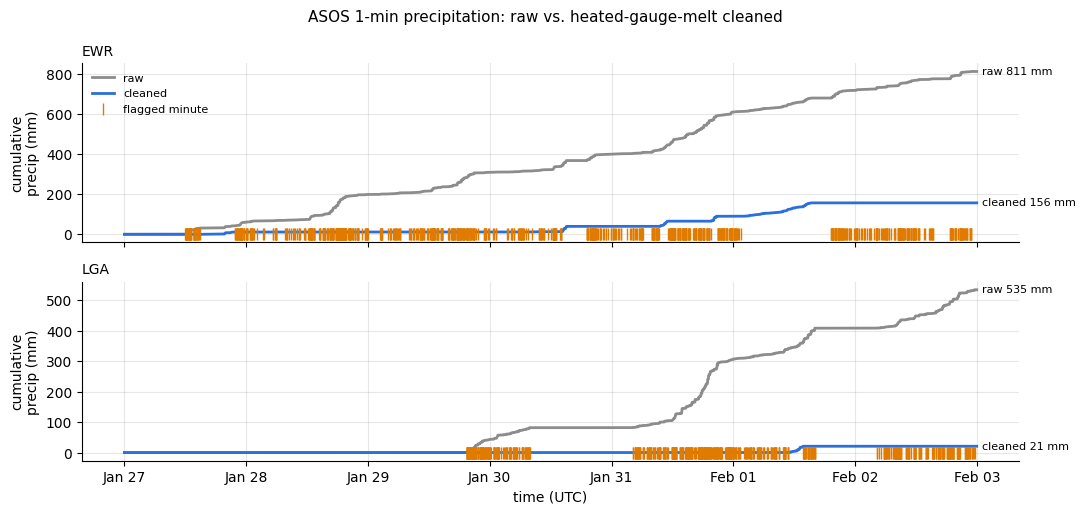

In [6]:
WN.plot_gauge_melt(ASOS);

## §6. Using it in your own analysis

- **Minute/hour-level comparisons** (e.g. CML attenuation vs. ASOS rain): keep the
  default `'mask'`. The melt water is real snowfall, but reported at the wrong time.
- **Storm totals** (how much water fell in the storm): use `'flag'` or `'off'` — the melt is that storm's snow.
- **Tuning:** the thresholds are arguments of `WN.asos_gauge_melt_mask(ds, wet_window=, max_temp_c=, snow_lookback=)`.

Below: a stricter rule (only ±60 min without wet codes, only ≤ 0 °C) flags less.

In [7]:
for sid, ds in ASOS.items():
    rain = ds['rainfall_amount'].values.ravel()
    default = WN.asos_gauge_melt_mask(ds).to_numpy()
    strict  = WN.asos_gauge_melt_mask(ds, wet_window='60min', max_temp_c=0.0,
                                      snow_lookback='0h').to_numpy()
    print(f'{sid}: flagged {np.nansum(rain[default]):6.1f} mm (default)   '
          f'{np.nansum(rain[strict]):6.1f} mm (strict)   of {np.nansum(rain):6.1f} mm raw')

EWR: flagged  654.6 mm (default)    585.0 mm (strict)   of  811.0 mm raw
LGA: flagged  514.1 mm (default)    452.6 mm (strict)   of  534.9 mm raw


**Validation.** Over 2023-10 → 2026-04 at EWR, JFK, LGA and NYC (1,688 complete
station-days), the raw ASOS / NOAA-GHCN-daily precipitation ratio is 0.98–1.77 per
station; after masking it is 0.96–1.10.

**Next:** [`src/analysis/analysis.ipynb`](../src/analysis/analysis.ipynb) — CML signal vs. weather.